# 05 — Shamal Regime and Transition Identification

This notebook creates the **ground-truth Shamal regime labels** required for the study:

**A Shamal-Transition-Aware Multi-Scale Residual Neural Network for Multi-Horizon Wind Vector Forecasting over the Persian Gulf and Gulf of Oman**

This notebook does **not train a forecasting model**.

It identifies strong regional Shamal events and creates four regime classes:

| Code | Regime |
|---:|---|
| 0 | Non-Shamal |
| 1 | Shamal onset / pre-event transition |
| 2 | Established Shamal |
| 3 | Shamal decay / post-event transition |

The primary event definition follows the strict Shamal criterion used by Al-Senafi and Anis (2015) and reaffirmed by recent Gulf research:

- WNW–N wind direction, approximately \(287^\circ\)–\(360^\circ\),
- hourly mean wind speed \(\ge 9.85\ \mathrm{m\,s^{-1}}\),
- qualifying conditions during at least 3 h in a day,
- at least 2 consecutive Shamal days for an event.

Because the original definition is station-based, this study makes one explicit gridded regional adaptation: a candidate **regional Shamal day** occurs when more than 50% of Persian Gulf study cells satisfy the local Shamal-day criterion. The regional 50% concept follows Yu et al. (2016).

For transition analysis, the two days immediately before and after an established event are treated as operational pre-/post-Shamal transition windows. This 48-h window is motivated by Li et al. (2020), who used two-day pre- and post-Shamal periods.

### Leakage rule

The labels generated here are ground truth for auxiliary targets and regime-conditioned evaluation.

They must **not** be inserted directly as forecast predictors because their definition can use future hours or future days. A later Shamal-aware model must learn future regime probabilities from causal information available at or before forecast issue time.


## 1. Methodological references

1. **Al-Senafi, F., & Anis, A. (2015).** *Shamals and climate variability in the Northern Arabian/Persian Gulf from 1973 to 2012.* International Journal of Climatology. DOI: `10.1002/joc.4302`

2. **Yu, Y., Notaro, M., Kalashnikova, O. V., & Garay, M. J. (2016).** *Climatology of summer Shamal wind in the Middle East.* Journal of Geophysical Research: Atmospheres. DOI: `10.1002/2015JD024063`

3. **Li, D., Anis, A., & Al Senafi, F. (2020).** *Physical response of the Northern Arabian Gulf to winter Shamals.* Journal of Marine Systems, 203, 103280. DOI: `10.1016/j.jmarsys.2019.103280`

4. **Alrushaid, T., & Al Senafi, F. (2026).** *Shamal winds and waves in the Arabian Gulf: variability and trends (1940–2024).* Journal of Coastal Conservation, 30, 67. DOI: `10.1007/s11852-026-01250-1`

There is no universally accepted Shamal definition. The present study therefore fixes one reproducible primary definition before model training and records all thresholds explicitly.


## 2. Imports and project paths

Inputs:

- `data/processed/yearly/`
- `data/processed/study_grid.csv`
- `data/splits/vector/split_manifest.csv`
- `outputs/tables/forecast_horizon_schema.csv`

Outputs:

- `data/processed/shamal/`
- `outputs/tables/`
- `outputs/figures/shamal/`


In [2]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


CWD = Path.cwd()

if (CWD / "data").exists() and (CWD / "notebooks").exists():
    PROJECT_ROOT = CWD
elif CWD.name == "notebooks" and (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise RuntimeError(
        "Could not locate the wind_paper project root. "
        "Run this notebook from the project root "
        "or from the notebooks directory."
    )


YEARLY_DIR = PROJECT_ROOT / "data" / "processed" / "yearly"
STUDY_GRID_PATH = PROJECT_ROOT / "data" / "processed" / "study_grid.csv"

VECTOR_SPLIT_MANIFEST_PATH = (
    PROJECT_ROOT / "data" / "splits" / "vector" / "split_manifest.csv"
)

FORECAST_HORIZON_SCHEMA_PATH = (
    PROJECT_ROOT / "outputs" / "tables" / "forecast_horizon_schema.csv"
)

SHAMAL_DIR = PROJECT_ROOT / "data" / "processed" / "shamal"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "shamal"

SHAMAL_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DAILY_DIAGNOSTICS_PATH = SHAMAL_DIR / "shamal_daily_diagnostics.nc"
HOURLY_LABELS_PATH = SHAMAL_DIR / "shamal_hourly_labels.nc"

EVENT_CATALOG_PATH = TABLES_DIR / "shamal_event_catalog.csv"
DEFINITION_CONFIG_PATH = TABLES_DIR / "shamal_definition_config.csv"
REGIME_SUMMARY_PATH = TABLES_DIR / "shamal_regime_summary.csv"
SPLIT_REGIME_SUMMARY_PATH = TABLES_DIR / "shamal_split_regime_summary.csv"
SENSITIVITY_PATH = TABLES_DIR / "shamal_regional_threshold_sensitivity.csv"

print("Project root:", PROJECT_ROOT.resolve())
print("Input yearly data:", YEARLY_DIR.resolve())
print("Shamal output:", SHAMAL_DIR.resolve())


Project root: /home/mike/Desktop/wind_paper
Input yearly data: /home/mike/Desktop/wind_paper/data/processed/yearly
Shamal output: /home/mike/Desktop/wind_paper/data/processed/shamal


## 3. Define the Shamal criteria

The strict high-Shamal criterion used here is:

\[
WS=\sqrt{u_{10}^2+v_{10}^2}
\]

with wind speed \(\ge 9.85\ \mathrm{m\,s^{-1}}\), wind from the WNW–N sector, at least 3 qualifying hourly observations per day, and at least 2 consecutive regional Shamal days per event.

The primary event detector is anchored to the Persian Gulf. Gulf of Oman coverage is retained as a diagnostic for downstream propagation and later forecast evaluation.

Transition windows are set to 48 h before and after each established event.


In [3]:
SHAMAL_SPEED_THRESHOLD_MS = 9.85
SHAMAL_DIRECTION_MIN_DEG = 287.0
SHAMAL_DIRECTION_MAX_DEG = 360.0

MIN_QUALIFYING_HOURS_PER_DAY = 3
MIN_CONSECUTIVE_SHAMAL_DAYS = 2

DETECTION_BASIN = "Persian Gulf"
REGIONAL_CELL_FRACTION_THRESHOLD = 0.50

ONSET_WINDOW_HOURS = 48
DECAY_WINDOW_HOURS = 48

REGIME_CODES = {
    0: "non_shamal",
    1: "onset",
    2: "established_shamal",
    3: "decay",
}

REGIONAL_THRESHOLD_SENSITIVITY = [0.45, 0.50, 0.55]

print("Speed threshold:", SHAMAL_SPEED_THRESHOLD_MS, "m/s")
print(
    "Direction sector:",
    SHAMAL_DIRECTION_MIN_DEG,
    "to",
    SHAMAL_DIRECTION_MAX_DEG,
    "degrees",
)
print("Minimum qualifying hours/day:", MIN_QUALIFYING_HOURS_PER_DAY)
print("Minimum consecutive days/event:", MIN_CONSECUTIVE_SHAMAL_DAYS)
print("Regional detection basin:", DETECTION_BASIN)
print("Regional fraction threshold: >50%")
print("Onset window:", ONSET_WINDOW_HOURS, "h")
print("Decay window:", DECAY_WINDOW_HOURS, "h")


Speed threshold: 9.85 m/s
Direction sector: 287.0 to 360.0 degrees
Minimum qualifying hours/day: 3
Minimum consecutive days/event: 2
Regional detection basin: Persian Gulf
Regional fraction threshold: >50%
Onset window: 48 h
Decay window: 48 h


## 4. Save the operational definition

The exact thresholds are stored in a configuration table so that the event-labeling method is reproducible and can be quoted directly in the manuscript.


In [4]:
definition_config = pd.DataFrame([
    {
        "parameter": "wind_speed_threshold_ms",
        "value": SHAMAL_SPEED_THRESHOLD_MS,
        "basis": "Al-Senafi and Anis (2015); Alrushaid and Al Senafi (2026)",
    },
    {
        "parameter": "direction_min_deg",
        "value": SHAMAL_DIRECTION_MIN_DEG,
        "basis": "Al-Senafi and Anis (2015); Alrushaid and Al Senafi (2026)",
    },
    {
        "parameter": "direction_max_deg",
        "value": SHAMAL_DIRECTION_MAX_DEG,
        "basis": "Al-Senafi and Anis (2015); Alrushaid and Al Senafi (2026)",
    },
    {
        "parameter": "minimum_qualifying_hours_per_day",
        "value": MIN_QUALIFYING_HOURS_PER_DAY,
        "basis": "Al-Senafi and Anis (2015)",
    },
    {
        "parameter": "minimum_consecutive_shamal_days",
        "value": MIN_CONSECUTIVE_SHAMAL_DAYS,
        "basis": "Al-Senafi and Anis (2015)",
    },
    {
        "parameter": "regional_detection_basin",
        "value": DETECTION_BASIN,
        "basis": "Study-specific gridded adaptation",
    },
    {
        "parameter": "regional_cell_fraction_threshold",
        "value": REGIONAL_CELL_FRACTION_THRESHOLD,
        "basis": "Adapted from Yu et al. (2016) regional >50% criterion",
    },
    {
        "parameter": "onset_window_hours",
        "value": ONSET_WINDOW_HOURS,
        "basis": "Operational adaptation of 2-day pre-Shamal period in Li et al. (2020)",
    },
    {
        "parameter": "decay_window_hours",
        "value": DECAY_WINDOW_HOURS,
        "basis": "Operational adaptation of 2-day post-Shamal period in Li et al. (2020)",
    },
    {
        "parameter": "labels_are_direct_predictors",
        "value": False,
        "basis": "Leakage prevention",
    },
])

definition_config.to_csv(DEFINITION_CONFIG_PATH, index=False)

print("Saved:", DEFINITION_CONFIG_PATH.resolve())
display(definition_config)


Saved: /home/mike/Desktop/wind_paper/outputs/tables/shamal_definition_config.csv


,parameter,value,basis
0,wind_speed_threshold_ms,9.85,Al-Senafi and Anis (2015); Alrushaid and Al Se...
1,direction_min_deg,287.0,Al-Senafi and Anis (2015); Alrushaid and Al Se...
2,direction_max_deg,360.0,Al-Senafi and Anis (2015); Alrushaid and Al Se...
3,minimum_qualifying_hours_per_day,3,Al-Senafi and Anis (2015)
4,minimum_consecutive_shamal_days,2,Al-Senafi and Anis (2015)
5,regional_detection_basin,Persian Gulf,Study-specific gridded adaptation
6,regional_cell_fraction_threshold,0.5,Adapted from Yu et al. (2016) regional >50% cr...
7,onset_window_hours,48,Operational adaptation of 2-day pre-Shamal per...
8,decay_window_hours,48,Operational adaptation of 2-day post-Shamal pe...
9,labels_are_direct_predictors,False,Leakage prevention


## 5. Validate the full hourly wind dataset and study grid

This step confirms:

- 16 annual files from 2005–2020,
- 512 study cells,
- 357 Persian Gulf cells,
- 155 Gulf of Oman cells,
- continuous hourly time axes,
- presence of `u10` and `v10`.


In [5]:
study_grid = pd.read_csv(STUDY_GRID_PATH)

assert len(study_grid) == 512
assert study_grid["study_id"].nunique() == 512
assert study_grid["grid_id"].nunique() == 512

assert set(study_grid["basin"].unique()) == {
    "Persian Gulf",
    "Gulf of Oman",
}

persian_gulf_ids = (
    study_grid.loc[
        study_grid["basin"] == "Persian Gulf",
        "study_id"
    ]
    .astype(int)
    .sort_values()
    .to_numpy()
)

gulf_of_oman_ids = (
    study_grid.loc[
        study_grid["basin"] == "Gulf of Oman",
        "study_id"
    ]
    .astype(int)
    .sort_values()
    .to_numpy()
)

assert len(persian_gulf_ids) == 357
assert len(gulf_of_oman_ids) == 155

expected_years = list(range(2005, 2021))
yearly_files = sorted(YEARLY_DIR.glob("*.nc"))
found_years = [int(file.stem) for file in yearly_files]

assert found_years == expected_years

previous_end = None

for file in yearly_files:
    with xr.open_dataset(file) as ds:
        assert "u10" in ds.data_vars
        assert "v10" in ds.data_vars
        assert "valid_time" in ds.dims
        assert "study_id" in ds.dims
        assert ds.sizes["study_id"] == 512

        times = pd.DatetimeIndex(
            pd.to_datetime(ds["valid_time"].values)
        )

        assert not times.has_duplicates
        assert times.is_monotonic_increasing

        differences = pd.Series(times).diff().dropna()
        assert (differences == pd.Timedelta(hours=1)).all()

        if previous_end is not None:
            assert times[0] - previous_end == pd.Timedelta(hours=1)

        previous_end = times[-1]

print("Full hourly wind dataset validation: PASSED")
print("Persian Gulf cells:", len(persian_gulf_ids))
print("Gulf of Oman cells:", len(gulf_of_oman_ids))
print("Annual files:", len(yearly_files))


Full hourly wind dataset validation: PASSED
Persian Gulf cells: 357
Gulf of Oman cells: 155
Annual files: 16


## 6. Wind speed and meteorological wind direction

ERA-style wind components describe the direction toward which air moves. Meteorological wind direction instead indicates the direction **from which** the wind comes.

The conversion used here is:

\[
\theta_{\mathrm{from}}
=
\left[
270^\circ
-
\operatorname{atan2}(v,u)
\frac{180^\circ}{\pi}
\right]
\bmod 360^\circ.
\]

A numerical direction of \(0^\circ\) is equivalent to \(360^\circ\) and is therefore included as due north.


In [6]:
def wind_speed(u, v):
    return np.sqrt(u ** 2 + v ** 2)


def meteorological_direction_from(u, v):
    # Output range: [0, 360)
    return (
        270.0
        - np.degrees(np.arctan2(v, u))
    ) % 360.0


def shamal_direction_mask(direction):
    # Strict WNW-N sector plus due north represented as 0 degrees.
    return (
        (direction >= SHAMAL_DIRECTION_MIN_DEG)
        |
        np.isclose(direction, 0.0, atol=1e-6)
    )


test_vectors = pd.DataFrame({
    "case": [
        "wind from north",
        "wind from west",
        "wind from east",
        "wind from south",
    ],
    "u": [0.0, 1.0, -1.0, 0.0],
    "v": [-1.0, 0.0, 0.0, 1.0],
})

test_vectors["direction_from_deg"] = meteorological_direction_from(
    test_vectors["u"].to_numpy(),
    test_vectors["v"].to_numpy(),
)

display(test_vectors)

assert np.isclose(
    test_vectors.loc[
        test_vectors["case"] == "wind from north",
        "direction_from_deg"
    ].iloc[0],
    0.0
)

assert np.isclose(
    test_vectors.loc[
        test_vectors["case"] == "wind from west",
        "direction_from_deg"
    ].iloc[0],
    270.0
)

print("Wind-direction conversion test: PASSED")


,case,u,v,direction_from_deg
0,wind from north,0.0,-1.0,0.0
1,wind from west,1.0,0.0,270.0
2,wind from east,-1.0,0.0,90.0
3,wind from south,0.0,1.0,180.0


Wind-direction conversion test: PASSED


## 7. Detect local Shamal days and regional spatial coverage

For every grid cell and hour:

1. calculate wind speed,
2. calculate meteorological wind direction,
3. identify hours satisfying the strict Shamal criterion.

Qualifying hours are counted by day.

A grid cell is a **local Shamal-day cell** when at least 3 hourly observations satisfy the strict criterion.

For each day, the fraction of local Shamal-day cells is calculated separately for the Persian Gulf and Gulf of Oman.

The primary regional candidate day is based on the Persian Gulf fraction.


In [8]:
daily_frames = []

for file in yearly_files:
    year = int(file.stem)

    print(f"Processing Shamal diagnostics for {year} ...")

    with xr.open_dataset(file) as ds:
        u = ds["u10"].astype(np.float32)
        v = ds["v10"].astype(np.float32)

        speed = wind_speed(u, v)

        direction = (
            270.0
            - np.degrees(np.arctan2(v, u))
        ) % 360.0

        direction_ok = (
            (direction >= SHAMAL_DIRECTION_MIN_DEG)
            |
            np.isclose(direction, 0.0, atol=1e-6)
        )

        speed_ok = speed >= SHAMAL_SPEED_THRESHOLD_MS

        qualifying_hour = direction_ok & speed_ok

        qualifying_hours_daily = (
            qualifying_hour
            .resample(valid_time="1D")
            .sum()
        )

        local_shamal_day = (
            qualifying_hours_daily
            >= MIN_QUALIFYING_HOURS_PER_DAY
        )

        pg_local = local_shamal_day.sel(
            study_id=persian_gulf_ids
        )

        oman_local = local_shamal_day.sel(
            study_id=gulf_of_oman_ids
        )

        pg_fraction = (
            pg_local
            .mean(dim="study_id")
            .values
            .astype(np.float32)
        )

        oman_fraction = (
            oman_local
            .mean(dim="study_id")
            .values
            .astype(np.float32)
        )

        pg_speed = speed.sel(study_id=persian_gulf_ids)
        oman_speed = speed.sel(study_id=gulf_of_oman_ids)

        pg_daily_mean_speed = (
            pg_speed
            .mean(dim="study_id")
            .resample(valid_time="1D")
            .mean()
            .values
            .astype(np.float32)
        )

        pg_daily_max_speed = (
            pg_speed
            .max(dim="study_id")
            .resample(valid_time="1D")
            .max()
            .values
            .astype(np.float32)
        )

        oman_daily_mean_speed = (
            oman_speed
            .mean(dim="study_id")
            .resample(valid_time="1D")
            .mean()
            .values
            .astype(np.float32)
        )

        oman_daily_max_speed = (
            oman_speed
            .max(dim="study_id")
            .resample(valid_time="1D")
            .max()
            .values
            .astype(np.float32)
        )

        daily_times = pd.DatetimeIndex(
            pd.to_datetime(
                qualifying_hours_daily["valid_time"].values
            )
        )

        annual_daily = pd.DataFrame({
            "date": daily_times,
            "persian_gulf_shamal_cell_fraction": pg_fraction,
            "gulf_of_oman_shamal_cell_fraction": oman_fraction,
            "persian_gulf_daily_mean_speed": pg_daily_mean_speed,
            "persian_gulf_daily_max_speed": pg_daily_max_speed,
            "gulf_of_oman_daily_mean_speed": oman_daily_mean_speed,
            "gulf_of_oman_daily_max_speed": oman_daily_max_speed,
        })

        annual_daily["regional_candidate_shamal_day"] = (
            annual_daily["persian_gulf_shamal_cell_fraction"]
            > REGIONAL_CELL_FRACTION_THRESHOLD
        )

        daily_frames.append(annual_daily)

        del (
            u,
            v,
            speed,
            direction,
            direction_ok,
            speed_ok,
            qualifying_hour,
            qualifying_hours_daily,
            local_shamal_day,
            pg_local,
            oman_local,
            pg_speed,
            oman_speed,
        )

    gc.collect()

daily_df = (
    pd.concat(daily_frames, ignore_index=True)
    .sort_values("date")
    .reset_index(drop=True)
)

expected_dates = pd.date_range(
    "2005-01-01",
    "2020-12-31",
    freq="1D"
)

assert pd.DatetimeIndex(daily_df["date"]).equals(expected_dates)

print("\nDaily Shamal diagnostics created")
print("Days:", f"{len(daily_df):,}")
print(
    "Candidate regional Shamal days:",
    int(daily_df["regional_candidate_shamal_day"].sum())
)

display(daily_df.head())


Processing Shamal diagnostics for 2005 ...
Processing Shamal diagnostics for 2006 ...
Processing Shamal diagnostics for 2007 ...
Processing Shamal diagnostics for 2008 ...
Processing Shamal diagnostics for 2009 ...
Processing Shamal diagnostics for 2010 ...
Processing Shamal diagnostics for 2011 ...
Processing Shamal diagnostics for 2012 ...
Processing Shamal diagnostics for 2013 ...
Processing Shamal diagnostics for 2014 ...
Processing Shamal diagnostics for 2015 ...
Processing Shamal diagnostics for 2016 ...
Processing Shamal diagnostics for 2017 ...
Processing Shamal diagnostics for 2018 ...
Processing Shamal diagnostics for 2019 ...
Processing Shamal diagnostics for 2020 ...

Daily Shamal diagnostics created
Days: 5,844
Candidate regional Shamal days: 246


,date,persian_gulf_shamal_cell_fraction,gulf_of_oman_shamal_cell_fraction,persian_gulf_daily_mean_speed,persian_gulf_daily_max_speed,gulf_of_oman_daily_mean_speed,gulf_of_oman_daily_max_speed,regional_candidate_shamal_day
0,2005-01-01,0.000000,0.212903,4.135284,8.660887,6.139166,11.944419,False
1,2005-01-02,0.000000,0.000000,3.071752,9.379150,2.386506,7.266950,False
2,2005-01-03,0.002801,0.000000,5.884066,12.726594,3.942850,9.152222,False
3,2005-01-04,0.000000,0.000000,4.773667,9.908784,4.005398,9.131408,False
4,2005-01-05,0.000000,0.000000,3.645370,10.544365,2.606464,6.246950,False


## 8. Identify established regional Shamal events

A candidate regional Shamal day becomes part of an established Shamal event only when the candidate condition persists for at least two consecutive days.

Runs are detected across the complete 2005–2020 daily sequence, including calendar-year boundaries.


In [9]:
candidate = daily_df[
    "regional_candidate_shamal_day"
].to_numpy(dtype=bool)

run_id = np.zeros(len(candidate), dtype=np.int32)

current_run = 0

for i in range(len(candidate)):
    if candidate[i]:
        if i == 0 or not candidate[i - 1]:
            current_run += 1
        run_id[i] = current_run

daily_df["candidate_run_id"] = run_id

candidate_run_lengths = (
    daily_df.loc[
        daily_df["candidate_run_id"] > 0
    ]
    .groupby("candidate_run_id")
    .size()
)

valid_run_ids = (
    candidate_run_lengths[
        candidate_run_lengths
        >= MIN_CONSECUTIVE_SHAMAL_DAYS
    ]
    .index
    .to_numpy()
)

daily_df["established_shamal_day"] = (
    daily_df["candidate_run_id"].isin(valid_run_ids)
)

valid_run_to_event = {
    int(run): event_id
    for event_id, run in enumerate(
        sorted(valid_run_ids),
        start=1
    )
}

daily_df["shamal_event_id"] = (
    daily_df["candidate_run_id"]
    .map(valid_run_to_event)
    .fillna(0)
    .astype(np.int32)
)

event_rows = []

for event_id in sorted(
    daily_df.loc[
        daily_df["shamal_event_id"] > 0,
        "shamal_event_id"
    ].unique()
):
    event_days = daily_df[
        daily_df["shamal_event_id"] == event_id
    ]

    event_rows.append({
        "event_id": int(event_id),
        "start_date": event_days["date"].min(),
        "end_date": event_days["date"].max(),
        "duration_days": len(event_days),
        "mean_persian_gulf_cell_fraction": (
            event_days["persian_gulf_shamal_cell_fraction"].mean()
        ),
        "peak_persian_gulf_cell_fraction": (
            event_days["persian_gulf_shamal_cell_fraction"].max()
        ),
        "mean_gulf_of_oman_cell_fraction": (
            event_days["gulf_of_oman_shamal_cell_fraction"].mean()
        ),
        "peak_gulf_of_oman_cell_fraction": (
            event_days["gulf_of_oman_shamal_cell_fraction"].max()
        ),
        "peak_persian_gulf_daily_wind_speed_ms": (
            event_days["persian_gulf_daily_max_speed"].max()
        ),
        "peak_gulf_of_oman_daily_wind_speed_ms": (
            event_days["gulf_of_oman_daily_max_speed"].max()
        ),
    })

event_catalog = pd.DataFrame(event_rows)

assert len(event_catalog) == len(valid_run_ids)

event_catalog.to_csv(EVENT_CATALOG_PATH, index=False)

print("Established Shamal events:", len(event_catalog))
print(
    "Established Shamal days:",
    int(daily_df["established_shamal_day"].sum())
)
print("Saved:", EVENT_CATALOG_PATH.resolve())

display(event_catalog.head(10))


Established Shamal events: 68
Established Shamal days: 162
Saved: /home/mike/Desktop/wind_paper/outputs/tables/shamal_event_catalog.csv


,event_id,start_date,end_date,duration_days,mean_persian_gulf_cell_fraction,peak_persian_gulf_cell_fraction,mean_gulf_of_oman_cell_fraction,peak_gulf_of_oman_cell_fraction,peak_persian_gulf_daily_wind_speed_ms,peak_gulf_of_oman_daily_wind_speed_ms
0,1,2005-03-24,2005-03-25,2,0.630252,0.731092,0.100000,0.193548,14.384679,12.627198
1,2,2005-04-05,2005-04-06,2,0.571429,0.593838,0.000000,0.000000,13.566449,10.182344
2,3,2005-06-07,2005-06-08,2,0.577031,0.630252,0.000000,0.000000,13.245287,8.922506
3,4,2005-12-26,2005-12-27,2,0.577031,0.596639,0.000000,0.000000,13.165414,9.213961
4,5,2006-07-08,2006-07-10,3,0.699346,0.806723,0.000000,0.000000,16.112476,11.325986
5,6,2006-12-28,2006-12-31,4,0.567227,0.647059,0.238710,0.522581,13.553967,12.193860
6,7,2007-07-15,2007-07-16,2,0.540616,0.554622,0.000000,0.000000,13.909862,8.771809
7,8,2007-12-22,2007-12-23,2,0.557423,0.577031,0.000000,0.000000,12.851211,8.531750
8,9,2008-01-06,2008-01-07,2,0.690476,0.775910,0.345161,0.664516,15.679963,13.522756
9,10,2008-01-31,2008-02-04,5,0.707563,0.848740,0.370323,0.961290,16.520655,16.794428


## 9. Create hourly onset, established, decay, and non-Shamal labels

Each established event is expanded to an hourly regime timeline.

- `0`: non-Shamal
- `1`: onset / pre-event transition
- `2`: established Shamal
- `3`: decay / post-event transition

If onset and decay windows overlap between nearby events, the non-established hour is assigned to the nearest event boundary. Established-event hours always have highest priority.


In [10]:
hourly_time = pd.date_range(
    "2005-01-01 00:00:00",
    "2020-12-31 23:00:00",
    freq="1h"
)

n_hours = len(hourly_time)

regime = np.zeros(n_hours, dtype=np.int8)
event_id_hourly = np.zeros(n_hours, dtype=np.int32)

hours_to_next_event = np.full(
    n_hours,
    np.inf,
    dtype=np.float32
)

hours_since_previous_event = np.full(
    n_hours,
    np.inf,
    dtype=np.float32
)

onset_event_id = np.zeros(n_hours, dtype=np.int32)
decay_event_id = np.zeros(n_hours, dtype=np.int32)

for row in event_catalog.itertuples(index=False):
    event_id = int(row.event_id)

    event_start = pd.Timestamp(row.start_date)

    event_end_exclusive = (
        pd.Timestamp(row.end_date)
        + pd.Timedelta(days=1)
    )

    established_mask = (
        (hourly_time >= event_start)
        &
        (hourly_time < event_end_exclusive)
    )

    regime[established_mask] = 2
    event_id_hourly[established_mask] = event_id

    onset_start = (
        event_start
        - pd.Timedelta(hours=ONSET_WINDOW_HOURS)
    )

    onset_mask = (
        (hourly_time >= onset_start)
        &
        (hourly_time < event_start)
    )

    onset_distance = np.asarray(
        (
            event_start
            - hourly_time[onset_mask]
        ) / pd.Timedelta(hours=1),
        dtype=np.float32
    )

    current_indices = np.where(onset_mask)[0]

    better = (
        onset_distance
        < hours_to_next_event[current_indices]
    )

    better_indices = current_indices[better]

    hours_to_next_event[better_indices] = onset_distance[better]
    onset_event_id[better_indices] = event_id

    decay_end = (
        event_end_exclusive
        + pd.Timedelta(hours=DECAY_WINDOW_HOURS)
    )

    decay_mask = (
        (hourly_time >= event_end_exclusive)
        &
        (hourly_time < decay_end)
    )

    decay_distance = np.asarray(
        (
            hourly_time[decay_mask]
            - event_end_exclusive
        ) / pd.Timedelta(hours=1),
        dtype=np.float32
    )

    current_indices = np.where(decay_mask)[0]

    better = (
        decay_distance
        < hours_since_previous_event[current_indices]
    )

    better_indices = current_indices[better]

    hours_since_previous_event[better_indices] = decay_distance[better]
    decay_event_id[better_indices] = event_id

non_established = regime != 2
has_onset = hours_to_next_event <= ONSET_WINDOW_HOURS
has_decay = hours_since_previous_event <= DECAY_WINDOW_HOURS

assign_onset = (
    non_established
    & has_onset
    & (
        (~has_decay)
        |
        (
            hours_to_next_event
            <= hours_since_previous_event
        )
    )
)

assign_decay = (
    non_established
    & has_decay
    & (~assign_onset)
)

regime[assign_onset] = 1
regime[assign_decay] = 3

event_id_hourly[assign_onset] = onset_event_id[assign_onset]
event_id_hourly[assign_decay] = decay_event_id[assign_decay]

print("Hourly regime labeling: COMPLETED")

unique_codes, unique_counts = np.unique(
    regime,
    return_counts=True
)

for code_value, count in zip(unique_codes, unique_counts):
    print(
        f"{int(code_value)} "
        f"({REGIME_CODES[int(code_value)]}): "
        f"{int(count):,} h"
    )


Hourly regime labeling: COMPLETED
0 (non_shamal): 130,056 h
1 (onset): 3,156 h
2 (established_shamal): 3,888 h
3 (decay): 3,156 h


## 10. Create multi-horizon future regime targets

For the same forecast horizons used by the wind-vector model,

\[
h\in\{1,3,6,12,24\}\ \mathrm{h},
\]

this notebook creates the future regime class \(R_{t+h}\).

These are auxiliary **targets**, not predictors.

The final hours of the complete record that lack a future target are assigned `-1`. Notebook 03/04 already excludes those unavailable forecast issue times from the modeling data.


In [11]:
assert FORECAST_HORIZON_SCHEMA_PATH.exists(), (
    "Missing forecast_horizon_schema.csv. Run Notebook 03 first."
)

forecast_horizon_schema = pd.read_csv(
    FORECAST_HORIZON_SCHEMA_PATH
)

FORECAST_HORIZONS = sorted(
    forecast_horizon_schema["horizon_hours"]
    .astype(int)
    .unique()
    .tolist()
)

regime_target = np.full(
    (n_hours, len(FORECAST_HORIZONS)),
    -1,
    dtype=np.int8
)

for horizon_index, horizon in enumerate(FORECAST_HORIZONS):
    regime_target[:-horizon, horizon_index] = regime[horizon:]

print("Forecast horizons:", FORECAST_HORIZONS)
print("Regime-target shape:", regime_target.shape)

alignment_time = pd.Timestamp("2015-06-15 12:00:00")
alignment_index = hourly_time.get_loc(alignment_time)

for horizon_index, horizon in enumerate(FORECAST_HORIZONS):
    expected = regime[alignment_index + horizon]
    actual = regime_target[alignment_index, horizon_index]
    assert actual == expected

print("Future regime-target alignment: PASSED")


Forecast horizons: [1, 3, 6, 12, 24]
Regime-target shape: (140256, 5)
Future regime-target alignment: PASSED


## 11. Save daily diagnostics and hourly labels

The notebook saves two NetCDF products.

### `shamal_daily_diagnostics.nc`

Contains daily spatial Shamal coverage and event diagnostics.

### `shamal_hourly_labels.nc`

Contains:

- hourly regime code,
- event association,
- future regime target at each forecast horizon.

The labels remain in a separate file so they cannot be accidentally confused with causal predictor variables.


In [12]:
daily_ds = xr.Dataset(
    data_vars={
        "persian_gulf_shamal_cell_fraction": (
            "date",
            daily_df[
                "persian_gulf_shamal_cell_fraction"
            ].to_numpy(dtype=np.float32)
        ),
        "gulf_of_oman_shamal_cell_fraction": (
            "date",
            daily_df[
                "gulf_of_oman_shamal_cell_fraction"
            ].to_numpy(dtype=np.float32)
        ),
        "persian_gulf_daily_mean_speed": (
            "date",
            daily_df[
                "persian_gulf_daily_mean_speed"
            ].to_numpy(dtype=np.float32)
        ),
        "persian_gulf_daily_max_speed": (
            "date",
            daily_df[
                "persian_gulf_daily_max_speed"
            ].to_numpy(dtype=np.float32)
        ),
        "gulf_of_oman_daily_mean_speed": (
            "date",
            daily_df[
                "gulf_of_oman_daily_mean_speed"
            ].to_numpy(dtype=np.float32)
        ),
        "gulf_of_oman_daily_max_speed": (
            "date",
            daily_df[
                "gulf_of_oman_daily_max_speed"
            ].to_numpy(dtype=np.float32)
        ),
        "regional_candidate_shamal_day": (
            "date",
            daily_df[
                "regional_candidate_shamal_day"
            ].to_numpy(dtype=np.int8)
        ),
        "established_shamal_day": (
            "date",
            daily_df[
                "established_shamal_day"
            ].to_numpy(dtype=np.int8)
        ),
        "shamal_event_id": (
            "date",
            daily_df[
                "shamal_event_id"
            ].to_numpy(dtype=np.int32)
        ),
    },
    coords={
        "date": pd.DatetimeIndex(daily_df["date"])
    }
)

daily_ds.attrs = {
    "definition": "Strict high-Shamal criterion with regional gridded adaptation",
    "speed_threshold_ms": SHAMAL_SPEED_THRESHOLD_MS,
    "direction_min_deg": SHAMAL_DIRECTION_MIN_DEG,
    "direction_max_deg": SHAMAL_DIRECTION_MAX_DEG,
    "minimum_qualifying_hours_per_day": MIN_QUALIFYING_HOURS_PER_DAY,
    "minimum_consecutive_days": MIN_CONSECUTIVE_SHAMAL_DAYS,
    "regional_detection_basin": DETECTION_BASIN,
    "regional_fraction_threshold": REGIONAL_CELL_FRACTION_THRESHOLD,
}

daily_ds.to_netcdf(DAILY_DIAGNOSTICS_PATH)

hourly_ds = xr.Dataset(
    data_vars={
        "regime_code": (
            "valid_time",
            regime
        ),
        "event_id": (
            "valid_time",
            event_id_hourly
        ),
        "regime_target": (
            ("valid_time", "horizon"),
            regime_target
        ),
    },
    coords={
        "valid_time": hourly_time,
        "horizon": np.asarray(
            FORECAST_HORIZONS,
            dtype=np.int16
        ),
    }
)

hourly_ds["regime_code"].attrs = {
    "class_0": "non_shamal",
    "class_1": "onset",
    "class_2": "established_shamal",
    "class_3": "decay",
    "use": (
        "Ground-truth label for auxiliary targets and "
        "regime-conditioned evaluation; do not use directly "
        "as a causal predictor."
    ),
}

hourly_ds["regime_target"].attrs = {
    "long_name": "Future Shamal regime class at each forecast horizon",
    "missing_code": -1,
    "class_0": "non_shamal",
    "class_1": "onset",
    "class_2": "established_shamal",
    "class_3": "decay",
}

hourly_ds.attrs = {
    "onset_window_hours": ONSET_WINDOW_HOURS,
    "decay_window_hours": DECAY_WINDOW_HOURS,
    "important": (
        "Transition and event labels may use future information "
        "and must not be supplied directly as forecast-time predictors."
    ),
}

hourly_ds.to_netcdf(HOURLY_LABELS_PATH)

print("Saved daily diagnostics:")
print(DAILY_DIAGNOSTICS_PATH.resolve())

print("\nSaved hourly labels:")
print(HOURLY_LABELS_PATH.resolve())


Saved daily diagnostics:
/home/mike/Desktop/wind_paper/data/processed/shamal/shamal_daily_diagnostics.nc

Saved hourly labels:
/home/mike/Desktop/wind_paper/data/processed/shamal/shamal_hourly_labels.nc


## 12. Overall regime-distribution summary

The class balance is inspected before model training.

This matters because established Shamal and transition states are likely to be much less frequent than ordinary conditions.

Any class weighting used later must be calculated from **training labels only**.


In [13]:
regime_summary_rows = []

for regime_code, regime_label in REGIME_CODES.items():
    count = int(np.sum(regime == regime_code))

    regime_summary_rows.append({
        "regime_code": regime_code,
        "regime_name": regime_label,
        "hours": count,
        "fraction": count / len(regime),
        "percent": 100.0 * count / len(regime),
    })

regime_summary = pd.DataFrame(regime_summary_rows)

regime_summary.to_csv(
    REGIME_SUMMARY_PATH,
    index=False
)

print("Overall regime distribution:")
display(regime_summary)

print("Saved:", REGIME_SUMMARY_PATH.resolve())


Overall regime distribution:


,regime_code,regime_name,hours,fraction,percent
0,0,non_shamal,130056,0.927276,92.727584
1,1,onset,3156,0.022502,2.250171
2,2,established_shamal,3888,0.027721,2.772074
3,3,decay,3156,0.022502,2.250171


Saved: /home/mike/Desktop/wind_paper/outputs/tables/shamal_regime_summary.csv


## 13. Audit regime classes inside train, validation, and test

The exact issue-time windows from Notebook 04 are used to summarize:

- current regime distribution,
- future regime-target distribution at each horizon,

for training, validation, and test separately.

This is diagnostic only. Test labels are not used for model tuning.


In [14]:
assert VECTOR_SPLIT_MANIFEST_PATH.exists(), (
    "Missing vector split manifest. Run Notebook 04 first."
)

split_manifest = pd.read_csv(
    VECTOR_SPLIT_MANIFEST_PATH,
    parse_dates=[
        "issue_start",
        "issue_end",
    ]
)

hourly_regime_series = pd.Series(
    regime,
    index=hourly_time,
    name="regime_code"
)

split_summary_rows = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    split_rows = split_manifest[
        split_manifest["split"] == split_name
    ]

    split_issue_parts = []

    for row in split_rows.itertuples(index=False):
        split_issue_parts.append(
            pd.date_range(
                row.issue_start,
                row.issue_end,
                freq="1h"
            )
        )

    split_issue_times = split_issue_parts[0]

    for part in split_issue_parts[1:]:
        split_issue_times = split_issue_times.append(part)

    current_codes = (
        hourly_regime_series
        .loc[split_issue_times]
        .to_numpy(dtype=np.int8)
    )

    for regime_code, regime_name in REGIME_CODES.items():
        count = int(np.sum(current_codes == regime_code))

        split_summary_rows.append({
            "split": split_name,
            "target_type": "current_regime_diagnostic",
            "horizon_hours": 0,
            "regime_code": regime_code,
            "regime_name": regime_name,
            "issue_times": len(current_codes),
            "class_count": count,
            "class_fraction": count / len(current_codes),
        })

    for horizon in FORECAST_HORIZONS:
        target_times = (
            split_issue_times
            + pd.Timedelta(hours=horizon)
        )

        target_codes = (
            hourly_regime_series
            .loc[target_times]
            .to_numpy(dtype=np.int8)
        )

        for regime_code, regime_name in REGIME_CODES.items():
            count = int(np.sum(target_codes == regime_code))

            split_summary_rows.append({
                "split": split_name,
                "target_type": "future_regime_target",
                "horizon_hours": horizon,
                "regime_code": regime_code,
                "regime_name": regime_name,
                "issue_times": len(target_codes),
                "class_count": count,
                "class_fraction": count / len(target_codes),
            })

split_regime_summary = pd.DataFrame(split_summary_rows)

split_regime_summary.to_csv(
    SPLIT_REGIME_SUMMARY_PATH,
    index=False
)

print("Split-specific regime audit:")
display(split_regime_summary.head(20))

print("Saved:", SPLIT_REGIME_SUMMARY_PATH.resolve())


Split-specific regime audit:


,split,target_type,horizon_hours,regime_code,regime_name,issue_times,class_count,class_fraction
0,train,current_regime_diagnostic,0,0,non_shamal,113760,104760,0.920886
1,train,current_regime_diagnostic,0,1,onset,113760,2772,0.024367
2,train,current_regime_diagnostic,0,2,established_shamal,113760,3456,0.030380
3,train,current_regime_diagnostic,0,3,decay,113760,2772,0.024367
4,train,future_regime_target,1,0,non_shamal,113760,104760,0.920886
5,train,future_regime_target,1,1,onset,113760,2772,0.024367
6,train,future_regime_target,1,2,established_shamal,113760,3456,0.030380
7,train,future_regime_target,1,3,decay,113760,2772,0.024367
8,train,future_regime_target,3,0,non_shamal,113760,104760,0.920886
9,train,future_regime_target,3,1,onset,113760,2772,0.024367


Saved: /home/mike/Desktop/wind_paper/outputs/tables/shamal_split_regime_summary.csv


## 14. Regional-threshold sensitivity analysis

The primary regional coverage threshold is \(>50\%\).

To evaluate whether the event catalog is overly sensitive to this adaptation, the same daily local Shamal classification is tested using regional coverage thresholds of:

\[
45\%,\quad 50\%,\quad 55\%.
\]

The physical wind-speed, direction, daily-duration, and two-consecutive-day criteria remain unchanged.


In [15]:
def count_events_from_candidate_days(
    candidate_days,
    minimum_days=2,
):
    candidate_days = np.asarray(
        candidate_days,
        dtype=bool
    )

    run_lengths = []
    current_length = 0

    for value in candidate_days:
        if value:
            current_length += 1
        elif current_length > 0:
            run_lengths.append(current_length)
            current_length = 0

    if current_length > 0:
        run_lengths.append(current_length)

    valid_lengths = [
        length
        for length in run_lengths
        if length >= minimum_days
    ]

    return (
        len(valid_lengths),
        int(np.sum(valid_lengths))
    )


sensitivity_rows = []

for threshold in REGIONAL_THRESHOLD_SENSITIVITY:
    candidate_days = (
        daily_df["persian_gulf_shamal_cell_fraction"]
        .to_numpy()
        > threshold
    )

    event_count, event_days = count_events_from_candidate_days(
        candidate_days,
        minimum_days=MIN_CONSECUTIVE_SHAMAL_DAYS,
    )

    sensitivity_rows.append({
        "regional_fraction_threshold": threshold,
        "candidate_shamal_days": int(candidate_days.sum()),
        "established_event_count": event_count,
        "established_event_days": event_days,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)

sensitivity_df.to_csv(
    SENSITIVITY_PATH,
    index=False
)

print("Regional threshold sensitivity:")
display(sensitivity_df)

print("Saved:", SENSITIVITY_PATH.resolve())


Regional threshold sensitivity:


,regional_fraction_threshold,candidate_shamal_days,established_event_count,established_event_days
0,0.45,313,95,228
1,0.50,246,68,162
2,0.55,188,47,112


Saved: /home/mike/Desktop/wind_paper/outputs/tables/shamal_regional_threshold_sensitivity.csv


## 15. Publication-oriented diagnostic figures

The notebook creates three quality-control figures:

1. annual established Shamal event count,
2. monthly established Shamal-day distribution,
3. hourly regime-class distribution.

These are diagnostic figures. Final manuscript graphics can be redesigned after model evaluation.


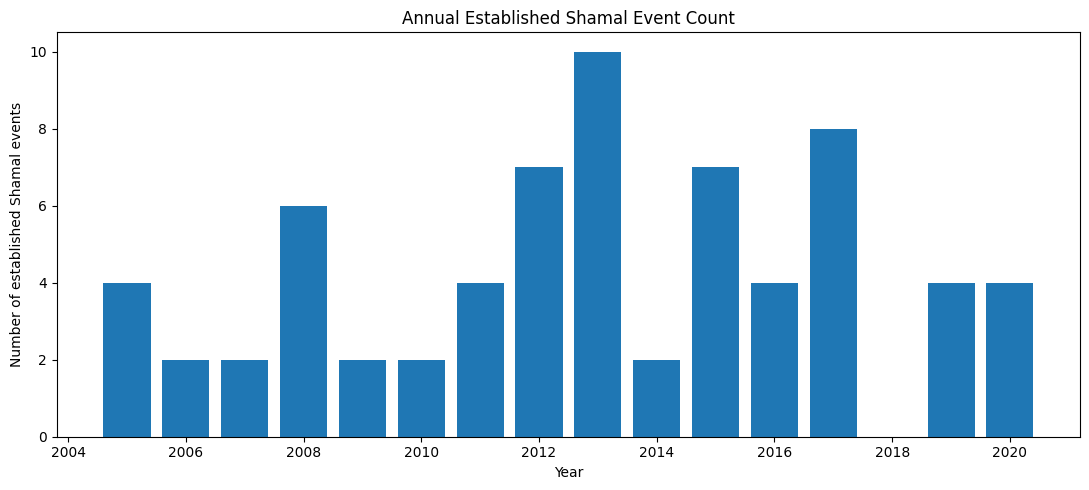

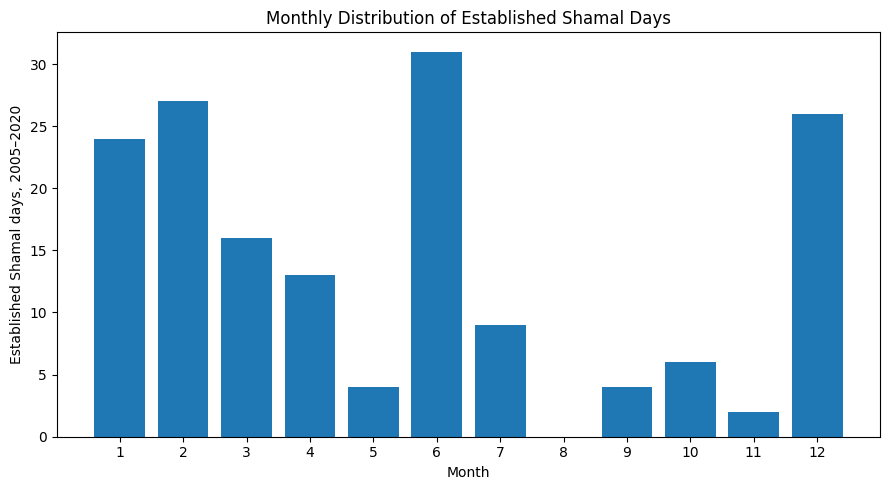

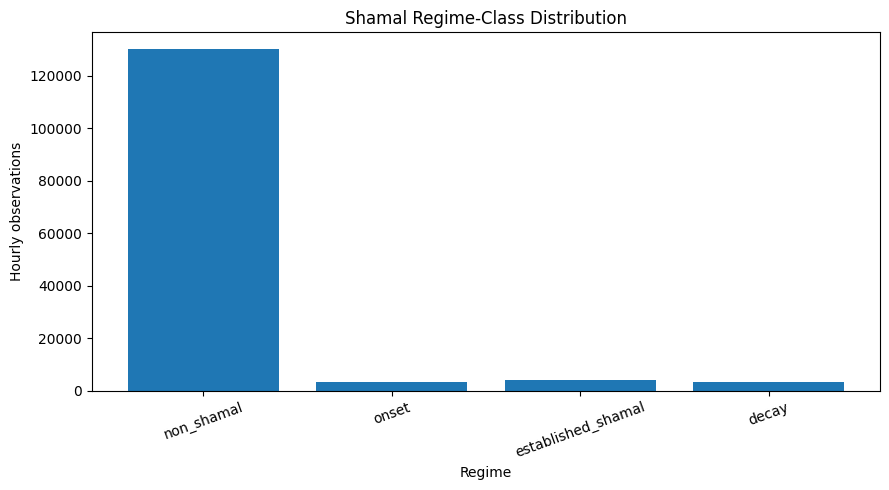

Saved figures:
/home/mike/Desktop/wind_paper/outputs/figures/shamal/annual_shamal_event_count.png
/home/mike/Desktop/wind_paper/outputs/figures/shamal/monthly_shamal_day_distribution.png
/home/mike/Desktop/wind_paper/outputs/figures/shamal/shamal_regime_class_distribution.png


In [16]:
if len(event_catalog) > 0:
    event_catalog_plot = event_catalog.copy()

    event_catalog_plot["start_year"] = pd.to_datetime(
        event_catalog_plot["start_date"]
    ).dt.year

    annual_event_counts = (
        event_catalog_plot
        .groupby("start_year")
        .size()
        .reindex(
            expected_years,
            fill_value=0
        )
    )
else:
    annual_event_counts = pd.Series(
        0,
        index=expected_years
    )


fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(111)

ax.bar(
    annual_event_counts.index,
    annual_event_counts.values
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of established Shamal events")
ax.set_title("Annual Established Shamal Event Count")

fig.tight_layout()

annual_figure_path = (
    FIGURES_DIR / "annual_shamal_event_count.png"
)

fig.savefig(
    annual_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


established_days = daily_df[
    daily_df["established_shamal_day"]
].copy()

established_days["month"] = (
    established_days["date"].dt.month
)

monthly_event_days = (
    established_days
    .groupby("month")
    .size()
    .reindex(
        range(1, 13),
        fill_value=0
    )
)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)

ax.bar(
    monthly_event_days.index,
    monthly_event_days.values
)

ax.set_xlabel("Month")
ax.set_ylabel("Established Shamal days, 2005–2020")
ax.set_title("Monthly Distribution of Established Shamal Days")
ax.set_xticks(range(1, 13))

fig.tight_layout()

monthly_figure_path = (
    FIGURES_DIR / "monthly_shamal_day_distribution.png"
)

fig.savefig(
    monthly_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111)

ax.bar(
    regime_summary["regime_name"],
    regime_summary["hours"]
)

ax.set_xlabel("Regime")
ax.set_ylabel("Hourly observations")
ax.set_title("Shamal Regime-Class Distribution")
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()

regime_figure_path = (
    FIGURES_DIR / "shamal_regime_class_distribution.png"
)

fig.savefig(
    regime_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Saved figures:")
print(annual_figure_path.resolve())
print(monthly_figure_path.resolve())
print(regime_figure_path.resolve())


## 16. Final scientific and leakage integrity checks

The final checks verify that:

- every established event lasts at least two days,
- established event days satisfy the regional candidate-day criterion,
- only regime codes 0–3 are present,
- established event hours have a positive event ID,
- future regime targets align exactly with the hourly regime sequence,
- unavailable future targets occur only at the end of the complete record,
- all required outputs exist.

**The true Shamal labels remain ground-truth targets/evaluation labels and must not be supplied directly as future-known model inputs.**


In [17]:
print("Running final Notebook 05 integrity checks ...")

if len(event_catalog) > 0:
    assert (
        event_catalog["duration_days"]
        >= MIN_CONSECUTIVE_SHAMAL_DAYS
    ).all()

assert (
    daily_df.loc[
        daily_df["established_shamal_day"],
        "regional_candidate_shamal_day"
    ]
).all()

assert set(
    np.unique(regime)
).issubset(
    set(REGIME_CODES.keys())
)

assert (
    event_id_hourly[
        regime == 2
    ]
    > 0
).all()

for horizon_index, horizon in enumerate(FORECAST_HORIZONS):
    assert np.array_equal(
        regime_target[:-horizon, horizon_index],
        regime[horizon:]
    )

    assert (
        regime_target[-horizon:, horizon_index]
        == -1
    ).all()

required_outputs = [
    DAILY_DIAGNOSTICS_PATH,
    HOURLY_LABELS_PATH,
    EVENT_CATALOG_PATH,
    DEFINITION_CONFIG_PATH,
    REGIME_SUMMARY_PATH,
    SPLIT_REGIME_SUMMARY_PATH,
    SENSITIVITY_PATH,
]

for path in required_outputs:
    assert path.exists(), (
        f"Missing required output: {path}"
    )

print("Event-duration rule: PASSED")
print("Regional-day rule: PASSED")
print("Regime-code integrity: PASSED")
print("Event-ID integrity: PASSED")
print("Future regime-target alignment: PASSED")
print("Saved-output integrity: PASSED")

print("\nEstablished events:", len(event_catalog))
print(
    "Established event days:",
    int(daily_df["established_shamal_day"].sum())
)
print(
    "Hourly labeled period:",
    hourly_time[0],
    "to",
    hourly_time[-1]
)

print("\nIMPORTANT:")
print(
    "True event/onset/decay labels are ground truth only."
)
print(
    "Do NOT feed future true Shamal labels directly "
    "into the forecasting model."
)

print("\n05_shamal_regime_identification.ipynb: COMPLETED")


Running final Notebook 05 integrity checks ...
Event-duration rule: PASSED
Regional-day rule: PASSED
Regime-code integrity: PASSED
Event-ID integrity: PASSED
Future regime-target alignment: PASSED
Saved-output integrity: PASSED

Established events: 68
Established event days: 162
Hourly labeled period: 2005-01-01 00:00:00 to 2020-12-31 23:00:00

IMPORTANT:
True event/onset/decay labels are ground truth only.
Do NOT feed future true Shamal labels directly into the forecasting model.

05_shamal_regime_identification.ipynb: COMPLETED


## Notebook 05 complete

The project now contains reproducible ground-truth labels for:

- **Non-Shamal**
- **Shamal onset / pre-event transition**
- **Established Shamal**
- **Shamal decay / post-event transition**

It also contains future regime targets aligned with the 1, 3, 6, 12, and 24 h wind-vector forecast horizons.

The next notebook should begin the baseline modeling stage:

`06_baseline_models.ipynb`

That notebook should use the exact split and scalers from Notebook 04 and use the Shamal labels from Notebook 05 only as auxiliary targets and regime-conditioned evaluation labels.
